# 📝 Product recommendation

## 🌟 Highlights
From this project "Product recommendation", the highlights are addressed as:
- EDA
  - Most of categories are apparel, accessories, and footwear
  - Footwear: More male products than females products.
  - Personal care/ Accessories: More female products than male products.
  - Products in summer season occupy big portion of dataset
  - Topwear and shoes are the main subcategory
  - Most of products in the dataset are from 2011 and 2012
- Choose MobileNetV2 as CNN model than VGG16 for friendly computation. (Run time drop from 110 mins to 18 mins)
- Batch loading is applied
- Cosine similarity to discover similar product
- Apply hard filter "subCategory" to increase recommendation performance
- Recommendation function call-out

## ℹ️ Project Introduction 
In the modern era, the rapid growth of data collection and analysis has led to data-driven world. Making decision based on data creates more efficient and precise outcome.  
Recommendation system is a kind of information filtering system. It analyzes similar contents and users to decide which items or product the user might like.  
This approach improves quality of search results and capability of providing more relevant information to users.  
There are 3 types of recommendation systems
- Content-based filtering: Recommend based on items with similar features and properties
- Collaborative filtering: Recommend based on what similar users already like
- Hybrid

**Product recommendation in this project recommends similar products to users based on content similarity**  
In this project, I will build up a recommendation system to recommend similar products according to similar features of products.  

## 🎯 Mission & Goal
As a data scentist working on a recommendation system, I am asked to build system to provide similar products to users, which has a potential to create more options to userss for product purchase based on their preferred taste. Eventually, this recommendation can bring up shopping experience and profit.  
  
**The outcome of this project should recommend products which are similar to user product input**

## 🧠 Thinking
To be able to recommend the product with similar features, we will need the following items:
- [x] product image dataset
- [x] Preprocess the dataset
- [x] Load the image
- [x] Convert the image (pixel block value) to numeric data that mechine recognizes
- [x] Extract the image features
- [x] Similarity analysis to judge similarity between product according to features
- [x] Function to recommend similar products from input product


## 🏭 Build Flow
- Import libraries
- Import dataset
- Inspect/preprocess the dataset
- Tensorflow way
  - Load the image
  - MobileNetV2 (since VGG16 is a heavy CNN)
  - Load training data after modeling from numpy
  - Similarity analysis - Cosine similarity
- Pytorch way
  - Load the image
  - MobileNetV2 for feature extraction
  - Similarity analysis - Cosine similarity
- Function to recommend similar products from input product

## 💡 To Do
- Issue found:
  - [x] cosine similarity cannot recommend product properly. Want apperal but it shows shoes/bag...  
     - Root cause: Cosine similarity returns angle between 2 vectors based on feature axis. It does not consider product category.  
       Thus, products with different categoery might still be recomended as long as cosine similarity is high  
     - Try: Give a hard filter to match category then find high cosine similarity  


### Import libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import plotly.express as px

from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import linear_kernel

# Image processing
from PIL import Image

# Show progress
from tqdm import tqdm

# Deep learning package
import torch
from torch import tensor
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
import torch.nn as nn
import torch.nn.functional as F

import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
# from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input


### Import dataset

In [2]:
base_path = r'D:\coding\2025\product_recommendation\product_dataset'
dataset_path = os.path.join(base_path, 'styles.csv')
print(dataset_path)
styles_df = pd.read_csv(dataset_path, on_bad_lines="skip")
styles_df

D:\coding\2025\product_recommendation\product_dataset\styles.csv


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt
...,...,...,...,...,...,...,...,...,...,...
44419,17036,Men,Footwear,Shoes,Casual Shoes,White,Summer,2013.0,Casual,Gas Men Caddy Casual Shoe
44420,6461,Men,Footwear,Flip Flops,Flip Flops,Red,Summer,2011.0,Casual,Lotto Men's Soccer Track Flip Flop
44421,18842,Men,Apparel,Topwear,Tshirts,Blue,Fall,2011.0,Casual,Puma Men Graphic Stellar Blue Tshirt
44422,46694,Women,Personal Care,Fragrance,Perfume and Body Mist,Blue,Spring,2017.0,Casual,Rasasi Women Blue Lady Perfume


In [3]:
# # ParserError: Error tokenizing data. C error: Expected 10 fields in line 6044, saw 11
# with open(dataset_path, 'r', encoding='utf-8') as f:
#     i = 0
#     for line in f:
#         i += 1
#         if i == 2:
#             print(line)
#         elif i == 6044:
#             print(line)
#             break
# print('See line 6044 has comma in the cell casuing the error')

### Inspect and preprocess the dataset
- [x] Datatype is proper ?
- [x] Missing value is cricial ?
- [x] Include image path in the dataframe
- [x] Visualize the dataset to have more insight
- [x] Keep necessary columns before loading the file

#### Datatype is proper ?

In [4]:
styles_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44424 entries, 0 to 44423
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  44424 non-null  int64  
 1   gender              44424 non-null  object 
 2   masterCategory      44424 non-null  object 
 3   subCategory         44424 non-null  object 
 4   articleType         44424 non-null  object 
 5   baseColour          44409 non-null  object 
 6   season              44403 non-null  object 
 7   year                44423 non-null  float64
 8   usage               44107 non-null  object 
 9   productDisplayName  44417 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 3.4+ MB


Data type is okay. No need to adjust

#### Missing value is cricial ?

In [5]:
styles_df.isnull().sum()

id                      0
gender                  0
masterCategory          0
subCategory             0
articleType             0
baseColour             15
season                 21
year                    1
usage                 317
productDisplayName      7
dtype: int64

Some missing value in some columns but I think it is okay for recommendation since recommendation is based on the pictures

#### Include image path in the dataframe

In [6]:
styles_df['Image_path'] = styles_df['id'].apply(lambda x: os.path.join(base_path, 'images', f'{x}.jpg'))

In [7]:
pd.set_option("display.max_colwidth", None)
# pd.reset_option("display.max_colwidth")
styles_df[['id', 'Image_path']]

,id,Image_path
0,15970,D:\coding\2025\product_recommendation\product_dataset\images\15970.jpg
1,39386,D:\coding\2025\product_recommendation\product_dataset\images\39386.jpg
2,59263,D:\coding\2025\product_recommendation\product_dataset\images\59263.jpg
3,21379,D:\coding\2025\product_recommendation\product_dataset\images\21379.jpg
4,53759,D:\coding\2025\product_recommendation\product_dataset\images\53759.jpg
...,...,...
44419,17036,D:\coding\2025\product_recommendation\product_dataset\images\17036.jpg
44420,6461,D:\coding\2025\product_recommendation\product_dataset\images\6461.jpg
44421,18842,D:\coding\2025\product_recommendation\product_dataset\images\18842.jpg
44422,46694,D:\coding\2025\product_recommendation\product_dataset\images\46694.jpg


In [8]:
styles_df['Image_path'].isnull().any()

False

Include image path in the dataframe for further image load process.  
Every image id has image path. So no missing data

In [9]:
styles_df

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,Image_path
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt,D:\coding\2025\product_recommendation\product_dataset\images\15970.jpg
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans,D:\coding\2025\product_recommendation\product_dataset\images\39386.jpg
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch,D:\coding\2025\product_recommendation\product_dataset\images\59263.jpg
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants,D:\coding\2025\product_recommendation\product_dataset\images\21379.jpg
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt,D:\coding\2025\product_recommendation\product_dataset\images\53759.jpg
...,...,...,...,...,...,...,...,...,...,...,...
44419,17036,Men,Footwear,Shoes,Casual Shoes,White,Summer,2013.0,Casual,Gas Men Caddy Casual Shoe,D:\coding\2025\product_recommendation\product_dataset\images\17036.jpg
44420,6461,Men,Footwear,Flip Flops,Flip Flops,Red,Summer,2011.0,Casual,Lotto Men's Soccer Track Flip Flop,D:\coding\2025\product_recommendation\product_dataset\images\6461.jpg
44421,18842,Men,Apparel,Topwear,Tshirts,Blue,Fall,2011.0,Casual,Puma Men Graphic Stellar Blue Tshirt,D:\coding\2025\product_recommendation\product_dataset\images\18842.jpg
44422,46694,Women,Personal Care,Fragrance,Perfume and Body Mist,Blue,Spring,2017.0,Casual,Rasasi Women Blue Lady Perfume,D:\coding\2025\product_recommendation\product_dataset\images\46694.jpg


#### Keep necessary columns before loading the file

In [10]:
styles_df_final = styles_df.drop('productDisplayName', axis=1)
styles_df_final
print(styles_df_final.shape)

# Deal with missing image
styles_df_final['Exists'] = styles_df_final['Image_path'].apply(lambda x: os.path.exists(x))
styles_df_final = styles_df_final.loc[styles_df_final['Exists'] == True, :]
styles_df_final.drop('Exists', axis=1, inplace=True)
styles_df_final = styles_df_final.reset_index(drop=True)  # drop=True: Do not keep old index as column
print(styles_df_final.shape)

(44424, 10)
(44419, 10)


#### Single image preprocessing 

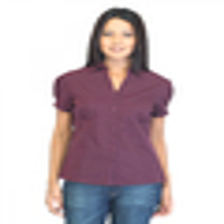

In [11]:
# Check the image
img = Image.open(r'D:\coding\2025\product_recommendation\product_dataset\images\26960.jpg')
img_resize = img.resize((224, 224))  # Resize to 224, 224
img_resize

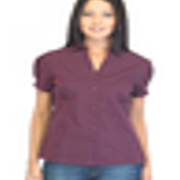

In [12]:
# Crop the image
start_x = 20
start_y = 20
end_x = 200
end_y = 200
img_crop = img.resize((224, 224)).crop((start_x, start_y, end_x, end_y))
img_crop

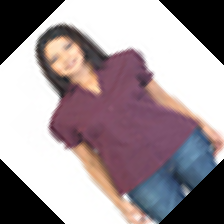

In [13]:
# Rotate the image
img_rotate = img.resize((224, 224)).rotate(45)
img_rotate

In [14]:
# Check image mode
img.mode

'RGB'

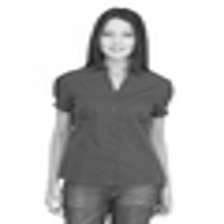

In [15]:
# Convert format
img_convert = img.resize((224, 224)).convert('L')
img_convert


In [16]:
# # Transform to tensor
# transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor(),
# ])

# img_tensor = transform(img)
# print(img_tensor.shape)
# img_tensor

In [17]:
# # Normalize the tensor
# r_mean = 0.5
# g_mean = 0.5
# b_mean = 0.5
# r_std = 1.5
# g_std = 1.5
# b_std = 1.5

# transform_r = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor(),
#     transforms.Normalize(
#         mean=[r_mean, g_mean, b_mean],
#         std=[r_std, g_std, b_std]
#     )
# ])

# img_norm = transform_r(img)
# print(img_norm.shape)
# img_norm

#### Visualize the dataset to have more insight

In [18]:
styles_df_category = styles_df.groupby(by='masterCategory')['masterCategory'].count().reset_index(name='Total').sort_values('Total', ascending=False)
styles_df_category
fig = px.bar(styles_df_category,
             x='masterCategory',
             y='Total',
             title='Category Count',
             height=400,
             width=400)
fig.update_xaxes(tickfont=dict(size=12))
fig.show()


Most of categories are apparel, accessories, and footwear. Will be good to use those for recommendation testing

In [19]:
styles_df_category_gender = styles_df.groupby(['masterCategory', 'gender'])['masterCategory'].count().reset_index(name='Total').sort_values('Total', ascending=False)
fig = px.bar(styles_df_category_gender,
             x='masterCategory',
             y='Total',
             title='Category Count',
             barmode='stack',
             color='gender',
             height=400,
             width=400)
fig.update_xaxes(tickfont=dict(size=12))
fig.show()

Group by category and gender to see the distribution.  
Most of the gender are men and women.  
Footwear: More male products than females products.  
Personal care/ Accessories: More female products than male products.  

In [20]:
styles_df_season = styles_df.groupby('season')['season'].count().reset_index(name='Total').sort_values('Total', ascending=False)

fig = px.bar(styles_df_season,
             x='season',
             y='Total',
             title='Season Distribution',
             height=400,
             width=400)
fig.update_xaxes(tickfont=dict(size=12))
fig.show()

Products in summer season occupy big portion of dataset

In [21]:
styles_df_sub = styles_df.groupby('subCategory')['subCategory'].count().reset_index(name='Total').sort_values('Total', ascending=False)
fig = px.bar(styles_df_sub,
             x='subCategory',
             y='Total',
             color='subCategory',
             title='Subcategory count',
             height=500,
             width=1000)

fig.show()

We can clearly see that topwear and shoes are the main subcategory in the dataset

In [22]:
styles_df_usage = styles_df.groupby('usage')['usage'].count().reset_index(name='Total').sort_values('Total', ascending=False)

fig = px.bar(styles_df_usage,
             x='usage',
             y='Total',
             title='Usage Distribution',
             height=400,
             width=400)
fig.update_xaxes(tickfont=dict(size=12))
fig.show()

Products are mostly casual in usage type

In [23]:
styles_df_year = styles_df.groupby('year')['year'].count().reset_index(name='Total')
fig = px.line(styles_df_year,
              x='year',
              y='Total',
              title='Trend of total product count by year',
              height=400,
              width=600)
fig.update_xaxes(tickangle=45, dtick=1, tickfont=dict(size=12))
fig.show()

Most of products in the dataset are from 2011 and 2012

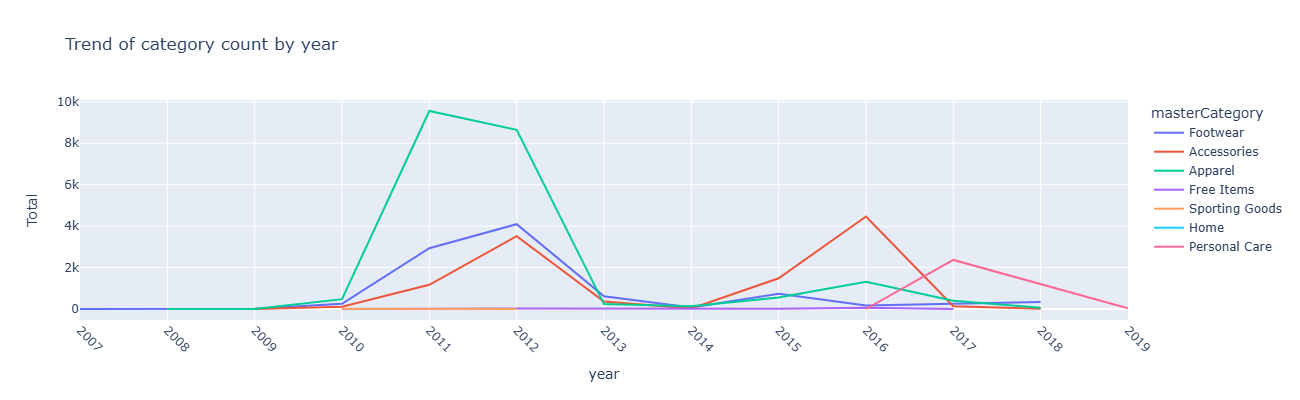

In [24]:
styles_df_year_category = styles_df.groupby(['year', 'masterCategory'])['masterCategory'].count().reset_index(name='Total')
fig = px.line(styles_df_year_category,
              x='year',
              y='Total',
              color='masterCategory',
              title='Trend of category count by year',
              height=400,
              width=600)
fig.update_xaxes(tickangle=45, dtick=1, tickfont=dict(size=12))
fig.show()

In the year of 2011 and 2012, apparel is the main category from the dataset.  
In the year of 2016, accessories is the main category.

### Pytorch way

#### Load the image

In [25]:
# Use iloc to split into test data and spare data since id is shuffled already.
total_image_count = styles_df_final.shape[0]
test = styles_df_final.iloc[:int(0.8*total_image_count),:]
spare = styles_df_final.iloc[int(0.8*total_image_count):,:]
print(test.shape)
print(spare.shape)
test.head(10)

(35535, 10)
(8884, 10)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,Image_path
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,D:\coding\2025\product_recommendation\product_dataset\images\15970.jpg
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,D:\coding\2025\product_recommendation\product_dataset\images\39386.jpg
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,D:\coding\2025\product_recommendation\product_dataset\images\59263.jpg
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,D:\coding\2025\product_recommendation\product_dataset\images\21379.jpg
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,D:\coding\2025\product_recommendation\product_dataset\images\53759.jpg
5,1855,Men,Apparel,Topwear,Tshirts,Grey,Summer,2011.0,Casual,D:\coding\2025\product_recommendation\product_dataset\images\1855.jpg
6,30805,Men,Apparel,Topwear,Shirts,Green,Summer,2012.0,Ethnic,D:\coding\2025\product_recommendation\product_dataset\images\30805.jpg
7,26960,Women,Apparel,Topwear,Shirts,Purple,Summer,2012.0,Casual,D:\coding\2025\product_recommendation\product_dataset\images\26960.jpg
8,29114,Men,Accessories,Socks,Socks,Navy Blue,Summer,2012.0,Casual,D:\coding\2025\product_recommendation\product_dataset\images\29114.jpg
9,30039,Men,Accessories,Watches,Watches,Black,Winter,2016.0,Casual,D:\coding\2025\product_recommendation\product_dataset\images\30039.jpg


In [28]:
# Define how to load images
class ImageDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df
        self.transform = transform

    def __len__(self):
        return self.df.shape[0]

    def __getitem__(self, idx):  # Load one image
        image_path = self.df.loc[idx, 'Image_path']
        image = Image.open(image_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image        

In [29]:
# Define transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]  
    )
])

imagedataset = ImageDataset(df=test, transform=transform)

In [30]:
# Batch loading
loader = DataLoader(dataset=imagedataset,
                    batch_size=32,
                    shuffle=False,
                   )

In [31]:
for img in loader:
    print(img.shape)
    break

torch.Size([32, 3, 224, 224])


#### MobileNetV2 for feature extraction

In [32]:
weights = MobileNet_V2_Weights.DEFAULT
model = mobilenet_v2(weights=weights)

# Define how to extract feature
feature_extractor = nn.Sequential(
    model.features,
    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten()
)


device = 'cuda' if torch.cuda.is_available() else 'cpu'
# Move model to certain device
feature_extractor = feature_extractor.to(device)

# Turn off training mode. Only for feature extraction
feature_extractor.eval()

Sequential(
  (0): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=1e-05, m

In [33]:
# Feature extraction for each image

if os.path.exists('all_features_pytorch.pt'):
    print('File exists. Loading the file')
    
    # Load tensor file
    all_features = torch.load('all_features_pytorch.pt')
    print(all_features.shape)

else:
    print('File does not exist. Feature extraction')
    
    all_features = []
    with torch.no_grad():  # Do not need to track gradient
        for images in tqdm(loader, desc='Extracting Features'):
            images = images.to(device)  # Move data to certain device

            features = feature_extractor(images)
            
            # Normalize feature vector to the length of 1
            features = F.normalize(features , p=2, dim=1)
            
            all_features.append(features.cpu())
    
    all_features = torch.cat(all_features, dim=0)
    
    # Save tensor in file
    torch.save(all_features, 'all_features_pytorch.pt')

File does not exist. Feature extraction


Extracting Features: 100%|█████████████████████████████████████████████████████████| 1111/1111 [18:08<00:00,  1.02it/s]


#### Similarity analysis - Cosine similarity

In [27]:
if os.path.exists('cosine_similarity_pytorch.pt'):
    print('File exists. Loading the file')
    cosine_similarity = torch.load('cosine_similarity_pytorch.pt')
    print(cosine_similarity.shape)

else:
    print('File does not exist. cosine similarity calculation')
    
    cosine_similarity = all_features @ all_features.T
    print(cosine_similarity.shape)
    torch.save(cosine_similarity, 'cosine_similarity_pytorch.pt')

File exists. Loading the file
torch.Size([35535, 35535])


In [26]:
cosine_similarity

NameError: name 'cosine_similarity' is not defined

### Function to recommend similar products from input product

In [37]:
test

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,Image_path
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,D:\coding\2025\product_recommendation\product_dataset\images\15970.jpg
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,D:\coding\2025\product_recommendation\product_dataset\images\39386.jpg
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,D:\coding\2025\product_recommendation\product_dataset\images\59263.jpg
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,D:\coding\2025\product_recommendation\product_dataset\images\21379.jpg
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,D:\coding\2025\product_recommendation\product_dataset\images\53759.jpg
...,...,...,...,...,...,...,...,...,...,...
35530,26805,Men,Apparel,Bottomwear,Trousers,Black,Summer,2012.0,Formal,D:\coding\2025\product_recommendation\product_dataset\images\26805.jpg
35531,29071,Unisex,Accessories,Bags,Backpacks,Green,Winter,2016.0,Casual,D:\coding\2025\product_recommendation\product_dataset\images\29071.jpg
35532,22499,Women,Footwear,Shoes,Heels,Gold,Winter,2015.0,Casual,D:\coding\2025\product_recommendation\product_dataset\images\22499.jpg
35533,30960,Women,Apparel,Topwear,Tunics,Black,Summer,2012.0,Ethnic,D:\coding\2025\product_recommendation\product_dataset\images\30960.jpg


##### Check which image read setting is bette. interpolation=None, lanczoc, or bicubic

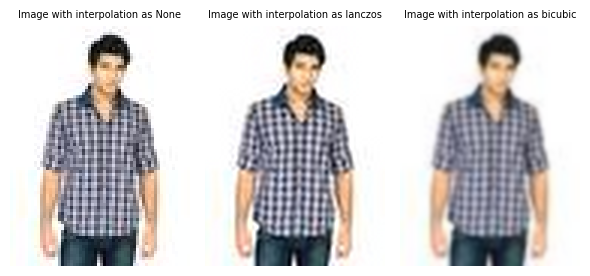

In [38]:
# Check which image read setting is better
pick_image_path = test.loc[0, 'Image_path']
img = Image.open(pick_image_path)

fig, axes = plt.subplots(1, 3, figsize=(6, 6))
interpolation_effect = ['None', 'lanczos', 'bicubic']
for i, effect in zip(range(3), interpolation_effect):
    axes[i].imshow(img, interpolation=effect)
    axes[i].set_title(f'Image with interpolation as {effect}', fontsize=7)
    axes[i].axis('off')
fig.tight_layout()
plt.show()

Image looks better when interpolation is lanczos

In [35]:
# a = df.loc[df['id']==18458]
# a

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,Image_path
3634,18458,Men,Personal Care,Fragrance,Deodorant,White,Spring,2017.0,Casual,D:\coding\2025\product_recommendation\product_dataset\images\18458.jpg


In [47]:
# for i in [3634, 27527, 16329, 26759, 450, 629, 11717]:
#     b = df[df.index == i]  
#     print(b)

         id gender masterCategory subCategory articleType baseColour  season  \
3634  18458    Men  Personal Care   Fragrance   Deodorant      White  Spring   

        year   usage  \
3634  2017.0  Casual   

                                                                  Image_path  
3634  D:\coding\2025\product_recommendation\product_dataset\images\18458.jpg  
          id gender masterCategory subCategory            articleType  \
27527  43962    Men  Personal Care   Fragrance  Perfume and Body Mist   

      baseColour  season    year   usage  \
27527      Brown  Spring  2017.0  Casual   

                                                                   Image_path  
27527  D:\coding\2025\product_recommendation\product_dataset\images\43962.jpg  
          id gender masterCategory subCategory            articleType  \
16329  23522    Men  Personal Care   Fragrance  Perfume and Body Mist   

      baseColour  season    year   usage  \
16329      Green  Spring  2017.0  Casual   



In [39]:
# df = test
# product_id = 18458
# input_product_index = df[df['id']==product_id].index  # Get input product index
# print(f'Input product index: {input_product_index}')
# input_product_subcategory = df.loc[input_product_index, 'subCategory'].values[0]  # Get input product subCategory as constraint
# print(f'Input product subcategory: {input_product_subcategory}')

# # input_product_constraint = list(df[df['subCategory']==input_product_subcategory].index)
# input_product_filter = list(df.loc[df['subCategory']==input_product_subcategory, :].index)  # Get index value from certain subCategory

# target_cosine_similarity = cosine_similarity[input_product_index,:]  # Get the specific row (input product) from cosine similarity 
# target_df = pd.DataFrame(target_cosine_similarity.T, columns=['Cosine Similarity'])
# print(target_df)

# # Only focus on products with the same category and sort the cosine similarity from high to low
# target_df_filter = target_df.iloc[input_product_filter, :].sort_values('Cosine Similarity', ascending=False)
# print(target_df_filter)
# # Recommend top products
# print(f'Top similar products with the same subcategory {input_product_subcategory}:\n{target_df_filter.head(7)}')
# recommended_product_indices = target_df_filter.iloc[0:7].index

Input product index: Int64Index([3634], dtype='int64')
Input product subcategory: Fragrance
       Cosine Similarity
0               0.437428
1               0.411790
2               0.341966
3               0.422722
4               0.431635
...                  ...
35530           0.451551
35531           0.370596
35532           0.383248
35533           0.455004
35534           0.364943

[35535 rows x 1 columns]
       Cosine Similarity
3634            1.000000
27527           0.707471
16329           0.697411
26759           0.693766
450             0.689436
...                  ...
24799           0.239024
18970           0.238867
23947           0.229408
18436           0.214457
24052           0.185368

[811 rows x 1 columns]
Top similar products with the same subcategory Fragrance:
       Cosine Similarity
3634            1.000000
27527           0.707471
16329           0.697411
26759           0.693766
450             0.689436
629             0.683474
11717           0.673521


Please input product id:  15970


Input product index: Int64Index([0], dtype='int64')
Input product subcategory: Topwear
Top similar products with the same subcategory Topwear:
       Cosine Similarity
0               1.000000
33414           0.946324
383             0.940219
659             0.939059
5766            0.938690
3899            0.937268
6391            0.936061
This is your input image: 15970


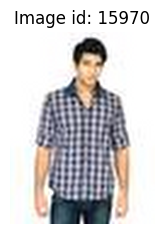

Recommended product index list: [33414, 383, 659, 5766, 3899, 6391]
Here are the recommended products that are similar to your input product id 15970


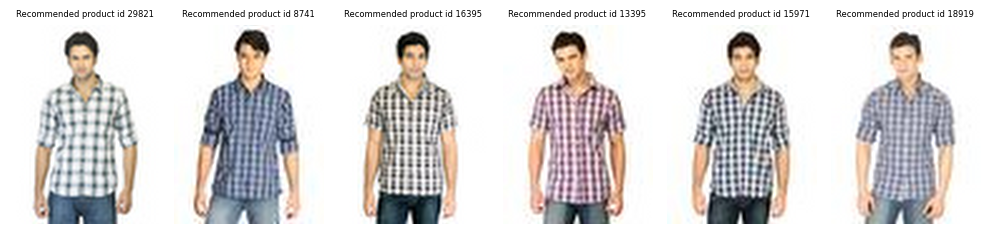

Please input product id:  1729


Input product index: Int64Index([6001], dtype='int64')
Input product subcategory: Shoes
Top similar products with the same subcategory Shoes:
       Cosine Similarity
6001            1.000000
9613            0.847941
19588           0.844777
23169           0.843925
12412           0.840734
7394            0.840437
1641            0.838360
This is your input image: 1729


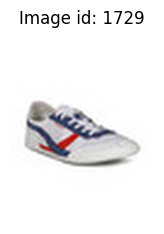

Recommended product index list: [9613, 19588, 23169, 12412, 7394, 1641]
Here are the recommended products that are similar to your input product id 1729


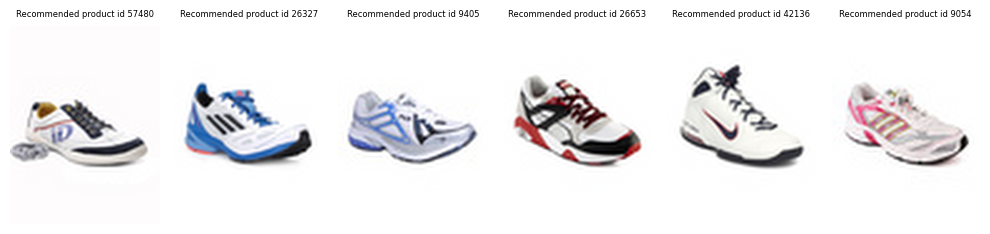

Please input product id:  2244


Input product index: Int64Index([515], dtype='int64')
Input product subcategory: Topwear
Top similar products with the same subcategory Topwear:
       Cosine Similarity
515             1.000000
8780            0.901570
25629           0.889450
16738           0.874163
12824           0.870744
13576           0.863176
11492           0.857316
This is your input image: 2244


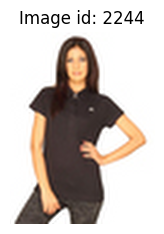

Recommended product index list: [8780, 25629, 16738, 12824, 13576, 11492]
Here are the recommended products that are similar to your input product id 2244


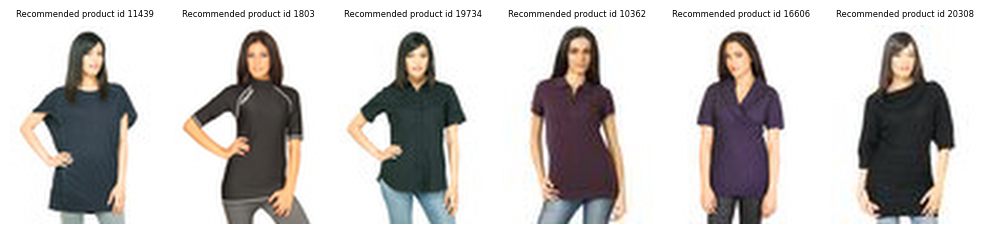

Please input product id:  39997


Product id does not exist


Please input product id:  40004


Input product index: Int64Index([31111], dtype='int64')
Input product subcategory: Eyewear
Top similar products with the same subcategory Eyewear:
       Cosine Similarity
31111           1.000000
13283           0.919513
16755           0.895436
13818           0.892318
25626           0.890036
1266            0.887200
17602           0.880085
This is your input image: 40004


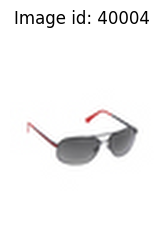

Recommended product index list: [13283, 16755, 13818, 25626, 1266, 17602]
Here are the recommended products that are similar to your input product id 40004


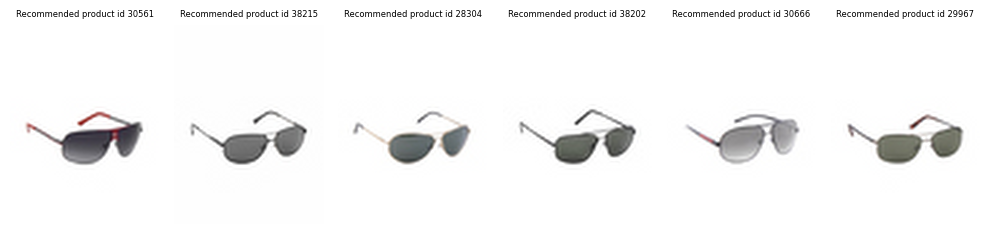

In [28]:
def recommend_product(product_id, df, similarity_factor=cosine_similarity):
    # Image id --> index --> cosine similarity --> Top similar products
    input_product_index = df[df['id']==product_id].index  # Get input product index
    print(f'Input product index: {input_product_index}')
    input_product_subcategory = df.loc[input_product_index, 'subCategory'].values[0]  # Get input product subCategory as constraint
    print(f'Input product subcategory: {input_product_subcategory}')
    
    # input_product_constraint = list(df[df['subCategory']==input_product_subcategory].index)
    input_product_filter = list(df.loc[df['subCategory']==input_product_subcategory, :].index)  # Get index value from certain subCategory
    
    target_cosine_similarity = cosine_similarity[input_product_index,:]  # Get the specific row (input product) from cosine similarity 
    target_df = pd.DataFrame(target_cosine_similarity.T, columns=['Cosine Similarity'])
    # print(target_df)

    # Only focus on products with the same category and sort the cosine similarity from high to low
    target_df_filter = target_df.iloc[input_product_filter, :].sort_values('Cosine Similarity', ascending=False)

    # Recommend top products
    print(f'Top similar products with the same subcategory {input_product_subcategory}:\n{target_df_filter.head(7)}')
    recommended_product_indices = target_df_filter.iloc[1:7].index

    # Show input image
    print(f'This is your input image: {product_id}')
    input_image_path = df.loc[input_product_index, 'Image_path'].values[0]
    img = Image.open(input_image_path)
    plt.figure(figsize=(2.5, 2.5))
    plt.imshow(img, interpolation='lanczos')
    plt.title(f'Image id: {product_id}')
    plt.axis('off')
    plt.show()

    # Show recommended images
    print(f'Recommended product index list: {list(recommended_product_indices)}')
    print(f'Here are the recommended products that are similar to your input product id {product_id}')
    fig, axes = plt.subplots(1, 6, figsize=(10, 7))
    # for i, index in zip(range(7), list(recommended_product_indices)):
    for i, index in enumerate(list(recommended_product_indices)):
        path = df.loc[index, 'Image_path']
        recommended_id = df.loc[index, 'id']
        img = Image.open(path)
        axes[i].imshow(img, interpolation='lanczos')
        axes[i].set_title(f'Recommended product id {recommended_id}', fontsize=6)
        axes[i].axis('off')
    fig.tight_layout()
    plt.show()

counter = 0
while counter <= 3:
    product_id = int(input('Please input product id: '))
    if product_id in list(test['id']):
        recommend_product(product_id, df=test)
        counter += 1
    else:
        print('Product id does not exist')

### TensorFlow way

#### Load the image
- Pre-prorcess: Use 80% of image for the project to reduce memory usage
- Use tf.keras.utils.image_dataset_from_directory if files are stored in directory structure
- Use tf.data.Dataset.from_tensor_slices when image path is stored in dataframe
  - It gives the full control of load and preprocess flow but we need to manually type in all the steps

In [20]:
# Use iloc to split into test data and spare data since id is shuffled already.
total_image_count = styles_df_final.shape[0]
test = styles_df_final.iloc[:int(0.8*total_image_count),:]
spare = styles_df_final.iloc[int(0.8*total_image_count):,:]
print(test.shape)
print(spare.shape)
test.head(10)

(35535, 10)
(8884, 10)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,Image_path
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,D:\coding\2025\product_recommendation\product_dataset\images\15970.jpg
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,D:\coding\2025\product_recommendation\product_dataset\images\39386.jpg
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,D:\coding\2025\product_recommendation\product_dataset\images\59263.jpg
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,D:\coding\2025\product_recommendation\product_dataset\images\21379.jpg
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,D:\coding\2025\product_recommendation\product_dataset\images\53759.jpg
5,1855,Men,Apparel,Topwear,Tshirts,Grey,Summer,2011.0,Casual,D:\coding\2025\product_recommendation\product_dataset\images\1855.jpg
6,30805,Men,Apparel,Topwear,Shirts,Green,Summer,2012.0,Ethnic,D:\coding\2025\product_recommendation\product_dataset\images\30805.jpg
7,26960,Women,Apparel,Topwear,Shirts,Purple,Summer,2012.0,Casual,D:\coding\2025\product_recommendation\product_dataset\images\26960.jpg
8,29114,Men,Accessories,Socks,Socks,Navy Blue,Summer,2012.0,Casual,D:\coding\2025\product_recommendation\product_dataset\images\29114.jpg
9,30039,Men,Accessories,Watches,Watches,Black,Winter,2016.0,Casual,D:\coding\2025\product_recommendation\product_dataset\images\30039.jpg


In [41]:
image_dataset_train = tf.data.Dataset.from_tensor_slices(test['Image_path'])

def load_and_preprocess(path):
    img = tf.io.read_file(path)  # Read file path and return raw image data
    img = tf.image.decode_jpeg(img, channels=3)  # Decode raw image data (jpg) into a tensor representing data, making sure it has red, green, blue channels
    img = tf.image.resize(img, [224, 224])  # Resize into 224 pixel in height and 224 pixel in width which is what feature extraction model desires
    img = preprocess_input(img)  # Preprocess the image tensor data channel order to BGR, subtrace ImageNet mean value per channel, and scale the pixel properly
    return img    

image_dataset_train = image_dataset_train.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE).batch(64).prefetch(tf.data.AUTOTUNE)
image_dataset_train

#### VGG16 model
- Instantiate VGG16
- Feature extration and feature vector output

In [20]:
# model = tf.keras.applications.VGG16(
#     include_top=False,  # Return feature extractor
#     weights='imagenet',  # Use pretrained weight vectors from ImageNet
#     input_tensor=None,
#     input_shape=(224, 224, 3),  # Match the image share defined previously
#     pooling='avg',  # Use global average pooling
#     classifier_activation='softmax'
# )

In [21]:
# train_pred = model.predict(image_dataset_train, verbose=1)
# print(train_pred.shape)
# np.save("train_features.npy", train_pred)

**Using VGG16 will take 1.5 hours to finish modeling**  
train_pred = model.predict(image_dataset_train, verbose=1)  
print(train_pred.shape)  
np.save("train_features.npy", train_pred)  
28/1111 ━━━━━━━━━━━━━━━━━━━━ 1:49:25 6s/step

**To speed up the modeling, we need to use more efficient model and parallelism technique**
- MobileNetV2 (still use pretrained data from ImageNet)
- Batch size
- Save to .nyp
- AUTOTUNE for parallel preprocess

#### MobileNetV2 model

In [34]:
model = tf.keras.applications.MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3),
    pooling='avg',
)

In [35]:
train_pred = model.predict(image_dataset_train, verbose=1)  # Use predict for feature extractor. Do not need .fit() since model is already trained (ImageNet)
print(train_pred.shape)
np.save("train_features.npy", train_pred)

556/556 [==============================] - 646s 1s/step
(35535, 1280)


**With the technique above (Using MobileNetV2, batch size modification, and parallelism) only takes 10 mins to finish modeling**  
4/556 [..............................] - ETA: 10:26

#### Load training data after modeling from numpy

In [20]:
train_pred_loaded = np.load('train_features.npy')
train_pred_loaded.shape

(35535, 1280)

In [21]:
print(train_pred_loaded)

[[0.0000000e+00 0.0000000e+00 0.0000000e+00 ... 3.7992728e-01
  0.0000000e+00 1.6143371e-04]
 [0.0000000e+00 6.5909229e-02 2.9041728e-02 ... 4.7265646e-01
  0.0000000e+00 1.9735131e-02]
 [2.0592619e-01 1.4880433e-03 0.0000000e+00 ... 9.2587703e-01
  1.8078238e-01 0.0000000e+00]
 ...
 [3.5445732e-01 4.1651341e-01 0.0000000e+00 ... 0.0000000e+00
  4.9265260e-03 5.1266438e-01]
 [4.1553810e-02 7.1180917e-02 4.9607676e-02 ... 8.0571270e-01
  3.0809504e-01 6.1809164e-01]
 [1.5422189e-02 7.8527558e-01 1.7916481e-01 ... 3.7173703e-01
  0.0000000e+00 4.8404713e-03]]


MobileNetV2 embedding has 1280 vectors

#### Similarity analysis
- Cosine similarity to directly compare the similarity of vectors
- Do dimension reduction and then compare similarity with machine learning model

**Cosine Similarity**

In [38]:
# Normalize the feature vectors to the length of 1
norms = np.linalg.norm(train_pred_loaded, axis=1, keepdims=True)
train_pred_loaded_norm = train_pred_loaded / norms
train_pred_loaded_norm.shape

# Cosine similarity by batch to reduce memory load
batch = 1000
size = train_pred_loaded_norm.shape[0]
cosine_similarity = np.zeros((size, size), dtype=np.float32)  # Initialize numpy matrix with zero

for i in range(0, size, batch):
    end_i = min(i + batch, size)
    train_batch = train_pred_loaded_norm[i: end_i]
    cosine_similarity[i: end_i] = np.dot(train_pred_loaded_norm[i: end_i], train_pred_loaded_norm.T)  # Same as linear_kernel(train_pred_loaded_norm[i: end_i], train_pred_loaded_norm)

# Save it into numpy file to reduct rerun all the time
np.save('cosine_similarity.npy', cosine_similarity)


In [22]:
# Load the cosine similarity numpy file for further use
cosine_similarity = np.load('cosine_similarity.npy')

cosine_similarity.shape

(35535, 35535)

In [32]:
train

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,Image_path
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,D:\coding\2025\product_recommendation\product_dataset\images\15970.jpg
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,D:\coding\2025\product_recommendation\product_dataset\images\39386.jpg
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,D:\coding\2025\product_recommendation\product_dataset\images\59263.jpg
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,D:\coding\2025\product_recommendation\product_dataset\images\21379.jpg
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,D:\coding\2025\product_recommendation\product_dataset\images\53759.jpg
...,...,...,...,...,...,...,...,...,...,...
35530,26805,Men,Apparel,Bottomwear,Trousers,Black,Summer,2012.0,Formal,D:\coding\2025\product_recommendation\product_dataset\images\26805.jpg
35531,29071,Unisex,Accessories,Bags,Backpacks,Green,Winter,2016.0,Casual,D:\coding\2025\product_recommendation\product_dataset\images\29071.jpg
35532,22499,Women,Footwear,Shoes,Heels,Gold,Winter,2015.0,Casual,D:\coding\2025\product_recommendation\product_dataset\images\22499.jpg
35533,30960,Women,Apparel,Topwear,Tunics,Black,Summer,2012.0,Ethnic,D:\coding\2025\product_recommendation\product_dataset\images\30960.jpg


##### Check which image read setting is bette. interpolation=None, lanczoc, or bicubic

In [ ]:
# Check which image read setting is better
pick_image_path = test.loc[0, 'Image_path']
img = Image.open(pick_image_path)

fig, axes = plt.subplots(1, 3, figsize=(6, 6))
interpolation_effect = ['None', 'lanczos', 'bicubic']
for i, effect in zip(range(3), interpolation_effect):
    axes[i].imshow(img, interpolation=effect)
    axes[i].set_title(f'Image with interpolation as {effect}', fontsize=7)
    axes[i].axis('off')
fig.tight_layout()
plt.show()

In [ ]:
def recommend_product(product_id, similarity_factor=cosine_similarity):
    # Image id --> index --> cosine similarity --> Top similar products
    input_product_index = train[train['id']==product_id].index  # Get input product index
    print(f'Input product index: {input_product_index}')
    input_product_subcategory = train.loc[input_product_index, 'subCategory'].values[0]  # Get input product subCategory as constraint
    print(f'Input product subcategory: {input_product_subcategory}')
    input_product_constraint = list(train[train['subCategory']==input_product_subcategory].index)
    
    target_cosine_similarity = cosine_similarity[input_product_index,:]  # Get row of input product from cosine similarity 
    target_df = pd.DataFrame(target_cosine_similarity.T, columns=['Cosine Similarity'])
    # print(target_df)
    target_df_constraint = target_df.loc[input_product_constraint,:].sort_values('Cosine Similarity', ascending=False)  # Only focus on products with the same category
    print(f'Top similar products with the same subcategory {input_product_subcategory}:\n{target_df_constraint.head(7)}')
    recommended_product_indices = target_df_constraint.iloc[0:7].index

    # Show input image
    print(f'This is your input image: {product_id}')
    input_image_path = train.loc[input_product_index, 'Image_path'].values[0]
    img = mpimg.imread(input_image_path)
    plt.figure(figsize=(2.5, 2.5))
    plt.imshow(img, interpolation='lanczos')
    plt.title(f'Image id: {product_id}')
    plt.axis('off')
    plt.show()

    # Show recommended images
    print(f'Recommended product index list: {list(recommended_product_indices)}')
    print(f'Here are the recommended products that are similar to your input product id {product_id}')
    fig, axes = plt.subplots(1, 7, figsize=(10, 7))
    for i, index in zip(range(7), list(recommended_product_indices)):
        path = train.loc[index, 'Image_path']
        recommended_id = train.loc[index, 'id']
        img = mpimg.imread(path)
        axes[i].imshow(img, interpolation='lanczos')
        axes[i].set_title(f'Recommended product id {recommended_id}', fontsize=6)
        axes[i].axis('off')
    fig.tight_layout()
    plt.show()

    # print(train.loc[list(recommended_product_indices),:])

counter = 0
while counter <= 3:
    product_id = int(input('Please input product id: '))
    if product_id in list(train['id']):
        recommend_product(product_id)
        counter += 1
    else:
        print('Product id does not exist')

**(Another) Similarity analysis - Dimension Reduction**  
Why do we need dimension reduction?
- After MobileNetV2 modeling, this feature vector dataset has 1280 dimensions
- To do recommendation for similar product, we need clustering ML model
- To visualize and reduce computation power requirement, we need to bring dataset from high dimension to low dimension
- Dimension reduction techniques are PCA, t-SNE, and UMAP.

In this section, we will do
- Dimension reduction
- Visualization

In [38]:
# PCA dimension reduction
pca = PCA(n_components=2)
train_pred_pca = pca.fit_transform(train_pred_loaded)
train_pred_pca_df = pd.DataFrame(train_pred_pca, columns=['Principal Component 1', 'Principal Component 2'])
train_with_pca = train.merge(train_pred_pca_df, how='left', left_index=True, right_index=True)
train_with_pca

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,Image_path,Principal Component 1,Principal Component 2
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,D:\coding\2025\product_recommendation\product_dataset\images\15970.jpg,7.701702,2.894805
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,D:\coding\2025\product_recommendation\product_dataset\images\39386.jpg,4.692341,2.455491
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,D:\coding\2025\product_recommendation\product_dataset\images\59263.jpg,-3.953993,-7.637794
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,D:\coding\2025\product_recommendation\product_dataset\images\21379.jpg,4.907312,1.630896
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,D:\coding\2025\product_recommendation\product_dataset\images\53759.jpg,11.178528,4.242432
...,...,...,...,...,...,...,...,...,...,...,...,...
35533,26805,Men,Apparel,Bottomwear,Trousers,Black,Summer,2012.0,Formal,D:\coding\2025\product_recommendation\product_dataset\images\26805.jpg,5.586874,-1.953346
35534,29071,Unisex,Accessories,Bags,Backpacks,Green,Winter,2016.0,Casual,D:\coding\2025\product_recommendation\product_dataset\images\29071.jpg,-6.532061,2.406865
35535,22499,Women,Footwear,Shoes,Heels,Gold,Winter,2015.0,Casual,D:\coding\2025\product_recommendation\product_dataset\images\22499.jpg,NaN,NaN
35536,30960,Women,Apparel,Topwear,Tunics,Black,Summer,2012.0,Ethnic,D:\coding\2025\product_recommendation\product_dataset\images\30960.jpg,NaN,NaN


#### Visualization of masterCategory from PCA 

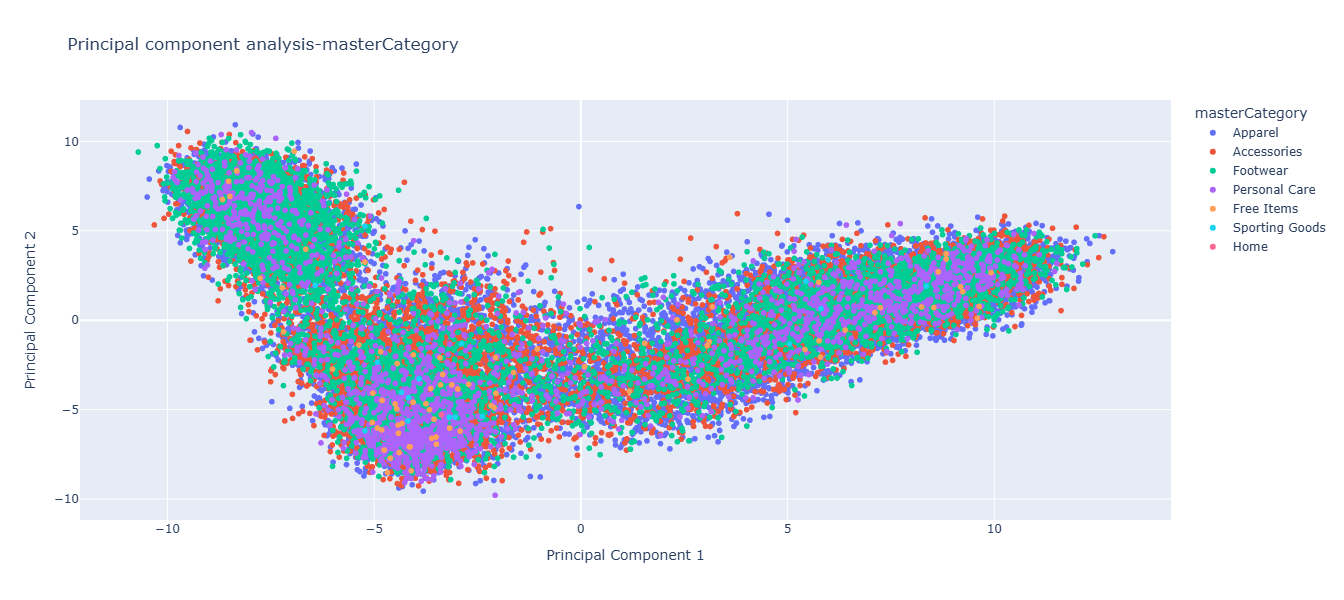

In [39]:
fig = px.scatter(train_with_pca,
                 x='Principal Component 1',
                 y='Principal Component 2',
                 color='masterCategory',
                 title='Principal component analysis-masterCategory',
                 height=600,
                 width=600)
fig.show()

#### Visualization of subCategory from PCA

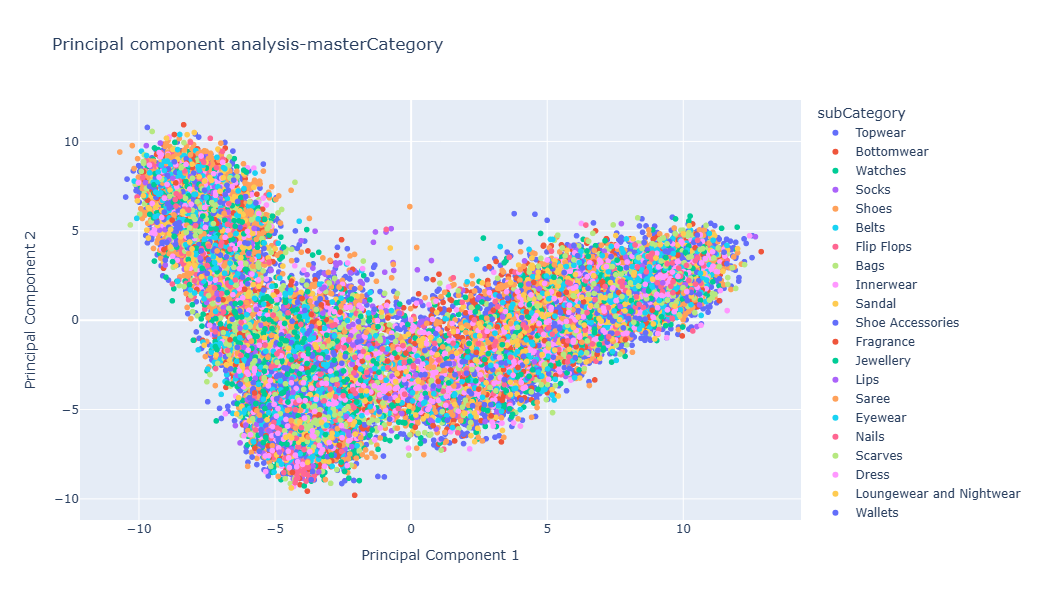

In [40]:
fig = px.scatter(train_with_pca,
                 x='Principal Component 1',
                 y='Principal Component 2',
                 color='subCategory',
                 title='Principal component analysis-subCategory',
                 height=600,
                 width=600)
fig.show()